 # Deep Learning - Assignment 2
 ## Siamese Networks for One-Shot Facial Recognition

 **Student Names:** Yuriy Rusanov, Elad Orpaz

 **ID(s):** 340915149, XXXXXXXXX

## 1. Setup and Imports

In [235]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import init
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time

In [236]:
# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


## 2. Configuration

In [237]:
# --- Dataset Configuration ---
DATA_DIR = 'data/lfw2'  # Root directory of the LFW dataset images
TRAIN_PAIRS_FILE = 'data/pairsDevTrain.txt'
TEST_PAIRS_FILE = 'data/pairsDevTest.txt'

# --- Image Preprocessing ---
IMG_SIZE = (105, 105)

# --- Dataset Configuration ---
VAL_SPLIT_RATIO = 0.2
BATCH_SIZE = 64  # Adjust based on GPU memory

# --- Device Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Dataset Parsing and Loading

 ### 3.1. Parse Pairs Files
 We need a function to read the `pairsDevTrain.txt` and `pairsDevTest.txt` files. These files have two formats:
 1.  **Positive Pairs:** `person_name\timg_num1\timg_num2` (Images of the same person)
 2.  **Negative Pairs:** `person_name1\timg_num1\tperson_name2\timg_num2` (Images of different people)

 We'll create pairs of image paths and a label (1 for same person, 0 for different).

In [238]:
def parse_pairs_file(file_path, data_dir):
    """
    Parses the LFW pairs file and returns a list of image pairs and labels.

    Args:
        file_path (str): Path to the pairs file (e.g., pairsDevTrain.txt).
        data_dir (str): Path to the directory containing LFW images.

    Returns:
        list: A list of tuples, where each tuple is ((img1_path, img2_path), label).
              label is 1 for a match (same person) and 0 for a mismatch.
    """
    pairs = []
    with open(file_path, 'r') as f:
        lines = f.readlines()
        num_pairs_info = int(lines[0].strip())  # First line contains the number of pairs of each type

        # Process lines for positive pairs (same person)
        for i in range(1, num_pairs_info + 1):
            line = lines[i].strip().split('\t')
            person_name = line[0]
            img_num1 = int(line[1])
            img_num2 = int(line[2])

            img1_path = os.path.join(data_dir, person_name, f"{person_name}_{img_num1:04d}.jpg")
            img2_path = os.path.join(data_dir, person_name, f"{person_name}_{img_num2:04d}.jpg")

            if os.path.exists(img1_path) and os.path.exists(img2_path):
                pairs.append(((img1_path, img2_path), 1))
            else:
                print(f"Warning: Image path not found for positive pair: {line}")

        # Process lines for negative pairs (different people)
        for i in range(num_pairs_info + 1, len(lines)):
            line = lines[i].strip().split('\t')
            person_name1 = line[0]
            img_num1 = int(line[1])
            person_name2 = line[2]
            img_num2 = int(line[3])

            img1_path = os.path.join(data_dir, person_name1, f"{person_name1}_{img_num1:04d}.jpg")
            img2_path = os.path.join(data_dir, person_name2, f"{person_name2}_{img_num2:04d}.jpg")

            if os.path.exists(img1_path) and os.path.exists(img2_path):
                pairs.append(((img1_path, img2_path), 0))
            else:
                print(f"Warning: Image path not found for negative pair: {line}")

    return pairs

In [239]:
# Parse the files
all_train_pairs = parse_pairs_file(TRAIN_PAIRS_FILE, DATA_DIR)
test_pairs = parse_pairs_file(TEST_PAIRS_FILE, DATA_DIR)

# Shuffle the training pairs before splitting
random.shuffle(all_train_pairs)

# Split the training pairs into actual training and validation sets
num_all_train = len(all_train_pairs)
num_validation = int(num_all_train * VAL_SPLIT_RATIO)
num_train = num_all_train - num_validation

train_pairs = all_train_pairs[:num_train]
validation_pairs = all_train_pairs[num_train:]  # Use the end portion for validation

print(f"Total original training pairs: {num_all_train}")
print(f"Number of actual training pairs: {len(train_pairs)}")
print(f"Number of validation pairs: {len(validation_pairs)}")
print(f"Number of testing pairs: {len(test_pairs)}")

Total original training pairs: 2200
Number of actual training pairs: 1760
Number of validation pairs: 440
Number of testing pairs: 1000


 ### 4.2. Define Image Transformations
 Convert images to the required size, convert to tensors, and normalize. We'll use standard ImageNet normalization values, although the paper uses a different approach. Convert to grayscale as LFW images are diverse, and color might not be the most reliable feature for identity. The paper also used grayscale.


In [240]:
# Define transformations - convert to grayscale, resize, convert to tensor, normalize
# Normalization for grayscale images (mean=0.5, std=0.5) to scale pixels to [-1, 1]
data_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize single channel
])

### 4.3. Create Custom PyTorch Dataset

In [241]:
class LFWPairsDataset(Dataset):
    """Custom Dataset for LFW pairs."""

    def __init__(self, pairs, transform=None):
        """
        Args:
            pairs (list): List of ((img1_path, img2_path), label) tuples.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        (img1_path, img2_path), label = self.pairs[idx]

        try:
            # Load as RGB (default for PIL unless image is already grayscale)
            img1 = Image.open(img1_path)
            img2 = Image.open(img2_path)
            # Ensure images are in RGB format if they might be palette-based, etc.
            if img1.mode != 'RGB':
                img1 = img1.convert('RGB')
            if img2.mode != 'RGB':
                img2 = img2.convert('RGB')

        except FileNotFoundError:
            print(f"Error loading images for index {idx}: {img1_path}, {img2_path}")
            raise

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        label_tensor = torch.tensor(label, dtype=torch.float32)
        return img1, img2, label_tensor

### 4.4. Instantiate Datasets and DataLoaders

In [242]:
train_dataset = LFWPairsDataset(pairs=train_pairs, transform=data_transforms)
validation_dataset = LFWPairsDataset(pairs=validation_pairs, transform=data_transforms)
test_dataset = LFWPairsDataset(pairs=test_pairs, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)  #
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


 ## 5. Siamese Network Architecture

 Implement the Siamese network. It consists of two identical CNN branches that share weights. These branches extract features (embeddings) from the input images. The embeddings are then compared, often using a distance metric (like L1 distance in the paper), followed by a final layer (e.g., linear + sigmoid) to predict similarity.

 We will loosely follow the architecture described in the Koch et al. paper:
 - Conv -> ReLU -> MaxPool
 - Conv -> ReLU -> MaxPool
 - Conv -> ReLU
 - Conv -> ReLU
 - Flatten
 - Linear (fully connected) -> Sigmoid (or just Linear for embedding)

 Then, compute L1 distance between the embeddings and pass through a final Linear layer + Sigmoid.


In [243]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim):
        super(SiameseNetwork, self).__init__()
        self.embedding_dim = embedding_dim

        # self.final_conv_output_size = 24
        self.final_conv_output_size = 6
        self.num_final_filters = 256
        flattened_size = self.num_final_filters * self.final_conv_output_size * self.final_conv_output_size  # 256*24*24 = 147456

        # Define the shared CNN branch (loosely based on Koch et al.)
        self.cnn_branch = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=10),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=7),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 128, kernel_size=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, self.num_final_filters, kernel_size=4),
            nn.ReLU(inplace=True),

            nn.Flatten(),  # Output: 256 * 6 * 6 = 9216

            # Note: The original paper has a final FC layer in the branch *before* distance calculation.
            # Let's add that FC layer here to produce the embeddings.
            nn.Linear(flattened_size, self.embedding_dim)
            # No final activation here for the embedding itself
        )

        # Final layer to compare embeddings
        # It takes the absolute difference |h1 - h2| and predicts similarity
        self.fc_final = nn.Sequential(
            nn.Linear(self.embedding_dim, 1),
            nn.Sigmoid()  # Output a probability (0=different, 1=same)
        )

        # Initialize weights (optional but often helpful)
        self._initialize_weights()

    # def _initialize_weights(self):
    #     """Initialize weights according to Koch et al. (2015), Section 3.2."""
    #     for m in self.modules():
    #         if isinstance(m, nn.Conv2d):
    #             # Conv Weights: N(0, 0.01), Bias: N(0.5, 0.01)
    #             init.normal_(m.weight, mean=0, std=0.01)
    #             if m.bias is not None:
    #                 init.normal_(m.bias, mean=0.5, std=0.01)
    #         elif isinstance(m, nn.Linear):
    #             # FC Weights: N(0, 0.2), Bias: N(0.5, 0.01)
    #             init.normal_(m.weight, mean=0, std=0.2)
    #             if m.bias is not None:
    #                 init.normal_(m.bias, mean=0.5, std=0.01)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)  # As per Koch et al. for FC layers
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.5)  # As per Koch et al. for FC layers

    def forward_one(self, x):
        """Passes one input through the shared CNN branch."""
        return self.cnn_branch(x)

    def forward(self, input1, input2):
        """Forward pass for the Siamese network."""
        # Get embeddings for both inputs
        output1 = self.forward_one(input1)
        output2 = self.forward_one(input2)

        # Calculate the L1 distance (absolute difference) between embeddings
        l1_distance = torch.abs(output1 - output2)

        # Pass the distance through the final classification layer
        similarity_score = self.fc_final(l1_distance)

        return similarity_score

 ## 6. Loss Function and Optimizer

 We'll use Binary Cross-Entropy Loss (`nn.BCELoss`) since the network outputs a probability between 0 and 1. Adam optimizer is a common choice.


In [257]:
# --- Training Configuration ---
NUM_EPOCHS = 10

# SGD
# LEARNING_RATE = 0.0001  # Initial LR (1e-5 is within paper's range [1e-4, 1e-1], though low)
# # Consider trying a higher initial LR like 1e-4 or 1e-3 if results are poor.
# WEIGHT_DECAY = 0.0001  # L2 regularization (1e-4 is within paper's range [0, 0.1])
# MOMENTUM = 0.5  # Fixed momentum for SGD (paper used layer-wise + schedule)
# LR_DECAY_GAMMA = 0.99  # Exponential decay factor per epoch (matches paper's 1% decay)

# ADAM
LEARNING_RATE = 0.00005
WEIGHT_DECAY = 0.0001  # L2 regularization (1e-4 is within paper's range [0, 0.1])
LR_DECAY_GAMMA = 0.99  # Exponential decay factor per epoch (matches paper's 1% decay)

# --- Siamese Network Configuration ---
EMBEDDING_DIM = 1024  # Example dimension, adjust based on architecture

In [258]:
model = SiameseNetwork(embedding_dim=EMBEDDING_DIM).to(DEVICE)
criterion = nn.BCELoss()

# Use SGD with Momentum and Weight Decay (L2 Regularization)
# optimizer = optim.SGD(
#     model.parameters(),
#     lr=LEARNING_RATE,
#     momentum=MOMENTUM,
#     weight_decay=WEIGHT_DECAY
# )

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Use Exponential Learning Rate Decay as described in the paper
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=LR_DECAY_GAMMA)
print(f"Using LR Scheduler: ExponentialLR with gamma={LR_DECAY_GAMMA}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

Using LR Scheduler: ExponentialLR with gamma=0.99

Total Trainable Parameters: 10,634,049


## 7. Training Loop

In [259]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Trains the model for one epoch and returns loss and accuracy."""
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    processed_batches = 0

    progress_bar = tqdm(dataloader, desc='Training', leave=False)

    for i, (img1, img2, labels) in enumerate(progress_bar):
        # Move data to the correct device
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(img1, img2)

        # Ensure labels are the correct shape [batch_size, 1] for BCELoss
        labels_unsqueezed = labels.unsqueeze(1)

        # Calculate loss
        loss = criterion(outputs, labels_unsqueezed)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # --- Calculate Accuracy ---
        predicted = (outputs > 0.5).float()  # Threshold at 0.5
        correct_predictions += (predicted == labels_unsqueezed).sum().item()
        total_samples += labels.size(0)
        # --- End Accuracy Calculation ---

        # Statistics
        running_loss += loss.item()
        processed_batches += 1

        # Update progress bar
        current_acc = correct_predictions / total_samples if total_samples > 0 else 0.0
        progress_bar.set_postfix({'loss': running_loss / processed_batches, 'acc': current_acc})

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = correct_predictions / total_samples if total_samples > 0 else 0.0
    return epoch_loss, epoch_accuracy  # Return both loss and accuracy

## 8. Evaluation Function

In [260]:
def evaluate(model, dataloader, criterion, device, desc='Evaluating'):  # Added desc parameter
    """Evaluates the model on the given dataset."""
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Use the provided description for the progress bar
    progress_bar = tqdm(dataloader, desc=desc, leave=False)

    with torch.no_grad():  # Disable gradient calculations
        for img1, img2, labels in progress_bar:
            # Move data to the correct device
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            # Forward pass
            outputs = model(img1, img2)

            # Ensure labels are the correct shape [batch_size, 1]
            labels_unsqueezed = labels.unsqueeze(1)

            # Calculate loss
            loss = criterion(outputs, labels_unsqueezed)
            running_loss += loss.item()

            # Calculate accuracy
            predicted = (outputs > 0.5).float()  # Threshold at 0.5 for prediction
            correct_predictions += (predicted == labels_unsqueezed).sum().item()
            total_samples += labels.size(0)

            # Update progress bar post_fix
            current_acc = correct_predictions / total_samples if total_samples > 0 else 0.0
            progress_bar.set_postfix({
                'loss': running_loss / len(dataloader),  # Avg loss *so far* in this evaluation
                'accuracy': current_acc
            })

    avg_loss = running_loss / len(dataloader)
    accuracy = correct_predictions / total_samples if total_samples > 0 else 0.0
    return avg_loss, accuracy

## 9. Main Training Execution

In [261]:
# Lists to store metrics for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# --- Initialization for Best Model Saving ---
best_val_accuracy = 0.0  # Initialize with 0.0, assuming accuracy is non-negative
BEST_MODEL_PATH = 'best_siamese_model_val_acc.pth'  # Path to save the best model weights

print("Starting Training...")
training_start_time = time.time()  # <<< Record training start time

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{NUM_EPOCHS} ---")

    # Train for one epoch
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f"Epoch {epoch + 1} Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

    # Evaluate on the validation set
    val_loss, val_accuracy = evaluate(model, validation_loader, criterion, DEVICE,
                                      desc='Validating')  # Use validation loader
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # --- Check if this is the best model based on validation accuracy ---
    if val_accuracy > best_val_accuracy:
        print(f"*** Validation accuracy improved ({best_val_accuracy:.4f} --> {val_accuracy:.4f}). Saving model... ***")
        best_val_accuracy = val_accuracy
        # Save the model's state dictionary
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"Best model saved to {BEST_MODEL_PATH}")

    print(f"Epoch {epoch + 1} Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

    scheduler.step()

training_end_time = time.time()  # <<< Record training end time
training_duration = training_end_time - training_start_time
print("\nTraining Finished!")
print(f"Total Training Time: {training_duration:.2f} seconds")

# --- Final Evaluation on the Test Set ---
print("\nEvaluating on the Test Set (One Time)...")
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.to(DEVICE)  # Ensure the model is on the correct device
final_test_loss, final_test_accuracy = evaluate(model, test_loader, criterion, DEVICE,
                                                desc='Testing')  # Use test loader
print(f"\nFinal Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy:.4f}")

Starting Training...

--- Epoch 1/10 ---


Training:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 1 Training Loss: 0.6953, Training Accuracy: 0.5312


Validating:   0%|          | 0/7 [00:00<?, ?it/s]

*** Validation accuracy improved (0.0000 --> 0.5909). Saving model... ***
Best model saved to best_siamese_model_val_acc.pth
Epoch 1 Validation Loss: 0.6565, Validation Accuracy: 0.5909

--- Epoch 2/10 ---


...

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 10 Validation Loss: 0.8249, Validation Accuracy: 0.6477

Training Finished!
Total Training Time: 49.68 seconds

Evaluating on the Test Set (One Time)...


C:\Users\rusanov\AppData\Local\Temp\ipykernel_14436\2821833319.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH))


Testing:   0%|          | 0/16 [00:00<?, ?it/s]


Final Test Loss: 0.6074
Final Test Accuracy: 0.6800



## 10. Results and Visualization

### 10.1. Plot Training and Validation Loss

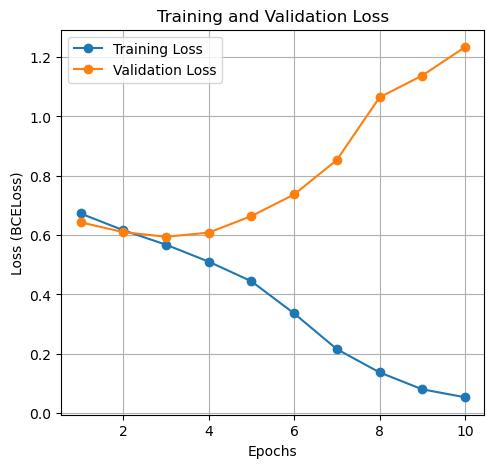

In [249]:
# Plot Training and Validation Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)  # Create subplot 1
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss', marker='o')  # Plot validation loss
plt.xlabel('Epochs')
plt.ylabel('Loss (BCELoss)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

### 10.2. Plot Training and Validation Accuracy

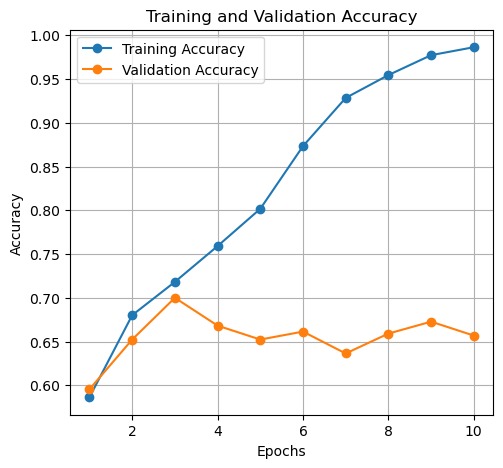

In [250]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)  # Create subplot 2
plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label='Training Accuracy', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label='Validation Accuracy', marker='o')  # Plot validation accuracy
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)


In [251]:
# Print final results again for clarity
print(f"\n--- Summary ---")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_accuracy:.4f}")


--- Summary ---
Final Training Loss: 0.0535
Final Training Accuracy: 0.9864
Final Validation Loss: 1.2333
Final Validation Accuracy: 0.6568
Final Test Loss: 0.6012
Final Test Accuracy: 0.6880
